In [1]:
!pip install pmdarima

In [2]:
from pandas_datareader import data as pdr #read data from yahoo finance api
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series

from statsmodels.tsa.stattools import adfuller # Augmented Dickey Fuller test for testing stationarity

from statsmodels.tsa.arima_model import ARIMA #for manual ARIMA
import pmdarima as pm #auto arima

In [49]:
er_visits_df = pd.read_csv('er_visits.csv')

er_visits_df

,week_end,geography,county,percent_visits_combined,percent_visits_covid,percent_visits_influenza,percent_visits_rsv,percent_visits_smoothed_combined,percent_visits_smoothed_covid,percent_visits_smoothed_influenza,percent_visits_smoothed_rsv,ed_trends_covid,ed_trends_influenza,ed_trends_rsv,hsa,hsa_counties,hsa_nci_id,fips,trend_source,BuildNumber
0,2022-10-01,Alabama,Bibb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Jefferson (Birmingham), AL - Shelby, AL","Bibb, Blount, Chilton, Cullman, Jefferson, She...",150,"1,007",HSA,2026-09-23
1,2022-10-01,Alabama,Calhoun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Calhoun (Anniston), AL - Cleburne, AL","Calhoun, Cleburne",177,"1,015",HSA,2026-09-23
2,2022-10-01,Alabama,Chilton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Jefferson (Birmingham), AL - Shelby, AL","Bibb, Blount, Chilton, Cullman, Jefferson, She...",150,"1,021",HSA,2026-09-23
3,2022-10-01,Alabama,Cleburne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Calhoun (Anniston), AL - Cleburne, AL","Calhoun, Cleburne",177,"1,029",HSA,2026-09-23
4,2022-10-01,Alabama,Coosa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Talladega, AL - Clay, AL","Clay, Coosa, Talladega",241,"1,037",HSA,2026-09-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664139,2026-09-19,Wyoming,Hot Springs,NaN,0.39,0.20,0.00,NaN,0.31,0.13,0.00,No Change,No Change,No Change,"Fremont, WY - Washakie, WY","Fremont, Hot Springs, Washakie",777,"56,017",HSA,2026-09-23
664140,2026-09-19,Wyoming,Lincoln,NaN,1.01,1.62,0.61,NaN,1.61,1.45,0.28,No Change,No Change,Limited Data,"Teton, WY - Lincoln, WY","Lincoln, Sublette, Teton",775,"56,023",HSA,2026-09-23
664141,2026-09-19,Wyoming,Natrona,NaN,0.00,0.00,0.00,NaN,0.02,0.02,0.00,No Change,No Change,No Change,"Natrona (Casper), WY - Converse, WY","Converse, Natrona",726,"56,025",HSA,2026-09-23
664142,2026-09-19,Wyoming,Sweetwater,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,Limited Data,Limited Data,Limited Data,"Sweetwater, WY",Sweetwater,977,"56,037",HSA,2026-09-23


### Filtering for Alleghany County

In [50]:
er_visits_alleghany = er_visits_df[(er_visits_df["county"]=="Allegheny") & 
                                   (er_visits_df["geography"]=="Pennsylvania")]
er_visits_alleghany.head()

,week_end,geography,county,percent_visits_combined,percent_visits_covid,percent_visits_influenza,percent_visits_rsv,percent_visits_smoothed_combined,percent_visits_smoothed_covid,percent_visits_smoothed_influenza,percent_visits_smoothed_rsv,ed_trends_covid,ed_trends_influenza,ed_trends_rsv,hsa,hsa_counties,hsa_nci_id,fips,trend_source,BuildNumber
8573,2022-12-10,Pennsylvania,Allegheny,6.36,NaN,NaN,NaN,6.65,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Allegheny (Pittsburgh), PA - Westmoreland, PA","Allegheny, Armstrong, Beaver, Butler, Indiana,...",42,"42,003",HSA,2026-09-23
22086,2023-04-08,Pennsylvania,Allegheny,1.30,NaN,NaN,NaN,1.15,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Allegheny (Pittsburgh), PA - Westmoreland, PA","Allegheny, Armstrong, Beaver, Butler, Indiana,...",42,"42,003",HSA,2026-09-23
23685,2023-04-22,Pennsylvania,Allegheny,0.92,NaN,NaN,NaN,0.87,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Allegheny (Pittsburgh), PA - Westmoreland, PA","Allegheny, Armstrong, Beaver, Butler, Indiana,...",42,"42,003",HSA,2026-09-23
25313,2023-05-06,Pennsylvania,Allegheny,0.69,NaN,NaN,NaN,0.69,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Allegheny (Pittsburgh), PA - Westmoreland, PA","Allegheny, Armstrong, Beaver, Butler, Indiana,...",42,"42,003",HSA,2026-09-23
26137,2023-05-13,Pennsylvania,Allegheny,0.63,NaN,NaN,NaN,0.60,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Allegheny (Pittsburgh), PA - Westmoreland, PA","Allegheny, Armstrong, Beaver, Butler, Indiana,...",42,"42,003",HSA,2026-09-23


In [51]:
er_visits_alleghany["week_end"] = pd.to_datetime(er_visits_alleghany["week_end"])

C:\Users\tanis\AppData\Local\Temp\ipykernel_20672\652600897.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  er_visits_alleghany["week_end"] = pd.to_datetime(er_visits_alleghany["week_end"])


### Checking where county level data is masked 

In [52]:
# # 1. Check where individual columns actually have non-null numbers
# valid_covid = er_visits_df[er_visits_df["percent_visits_covid"].notna()]
# print("Geographies with valid Covid values:")
# print(valid_covid[["geography", "county"]].drop_duplicates().head(10))

# # 2. Check Pennsylvania specifically
# pa_data = er_visits_df[er_visits_df["geography"] == "Pennsylvania"]
# print("\nPennsylvania summary counts per county:")
# print(pa_data.groupby("county")[["percent_visits_covid", "percent_visits_combined"]].count())

#### Approach 1: If we want to forecast for only pittsburgh, then we cannot forecast the diseases individually and can only look at the combined variable

##### Step 1: Filter out the relevant data

In [53]:
allegheny_resp = er_visits_alleghany[[
    "week_end", "percent_visits_combined" 
]]
allegheny_resp.head()

,week_end,percent_visits_combined
8573,2022-12-10,6.36
22086,2023-04-08,1.30
23685,2023-04-22,0.92
25313,2023-05-06,0.69
26137,2023-05-13,0.63


In [54]:
allegheny_resp = allegheny_resp.set_index("week_end")
allegheny_resp.head()

,percent_visits_combined
week_end,
2022-12-10,6.36
2023-04-08,1.30
2023-04-22,0.92
2023-05-06,0.69
2023-05-13,0.63


##### Step 2: Linear Interpolation for NaN Values

It would make sense to linearly interpolate normally if at most, the gap is of around 1-2 weeks. Any more than that (e.g., 3+ consecutive nan values) and we will be making a "big" assumption that the ER visits followed a linear/ straight line trend from thte preceding to the succeeding value for those 3+ weeks straight. So, first we check if there really are any 3+ weeks gap at all

In [55]:
# Check if Allegheny County even has multi-week gaps
is_na = allegheny_resp["percent_visits_combined"].isna()
missing_runs = is_na.groupby((~is_na).cumsum()).sum()
long_gaps = missing_runs[missing_runs > 0]

print("Distribution of missing run lengths (in weeks):")
print(long_gaps.value_counts())

Distribution of missing run lengths (in weeks):
percent_visits_combined
27    2
30    1
19    1
Name: count, dtype: int64


We have two gaps lasting 27 weeks (!), one gap lasting 30 weeks, and one lasting 19 weeks. Next step is to find where these gaps are.
* If they are all concentrated at the beginning of the data, we can simply truncate 
* If they are scattered, it could indicate that the reporting is seasonal (that is, Allegheny County simply turns on the reporting during peak seasons and not the off season).

In [57]:
# Inspect valid vs missing date ranges
allegheny_reset_index = allegheny_resp.reset_index()
valid_dates = allegheny_reset_index[allegheny_reset_index["percent_visits_combined"].notna()]["week_end"]
print(f"Data Starts: {valid_dates.min().date()}")
print(f"Data Ends:   {valid_dates.max().date()}")
print(f"Total Non-Null Weeks: {len(valid_dates)}")

# Locate the gap windows
is_null = allegheny_reset_index["percent_visits_combined"].isna()
allegheny_reset_index["gap_id"] = (~is_null).cumsum()
gap_summary = allegheny_reset_index[is_null].groupby("gap_id")["week_end"].agg(["min", "max", "count"])
gap_summary.columns = ["Gap_Start", "Gap_End", "Consecutive_Weeks"]
print("\nExact Dates of Multi-Week Gaps:")
print(gap_summary[gap_summary["Consecutive_Weeks"] > 2])

Data Starts: 2022-10-01
Data Ends:   2024-09-28
Total Non-Null Weeks: 105

Exact Dates of Multi-Week Gaps:
        Gap_Start    Gap_End  Consecutive_Weeks
gap_id                                         
24     2024-10-26 2026-08-29                 27
52     2024-10-19 2026-09-12                 27
76     2024-10-05 2026-08-15                 30
105    2024-11-30 2026-09-19                 19


Interpretation: There is no "historical" missing data! We have 102 weeks worth of continuous data. The missing data are all in the future respective to when the data was collected. But notice, that even in the gaps, there are overlapping dates. This might be because the data of Allegheny County has multiple hospital reporting areas (HSAs). So we need to either choose one HSA so that each week has only one value (including the missing week) or average across all HSAs

In [59]:
# going back to the er_visits_allegheny data #CHANGE SPELLING 
er_visits_alleghany["hsa"].value_counts()

hsa
Allegheny (Pittsburgh), PA - Westmoreland, PA    208
Name: count, dtype: int64

Interesting. I see only one HSA for the Allegheny County. So the duplicating dates might have been because of some other reason I have to investigate now. 

In [58]:
# Check why there are duplicate weeks for Allegheny County
allegheny_raw = er_visits_df[
    (er_visits_df["geography"] == "Pennsylvania") & 
    (er_visits_df["county"] == "Allegheny")
]

# Display columns that vary across the same week
sample_week = allegheny_raw[allegheny_raw["week_end"] == "2024-09-28"]
print("Columns distinguishing duplicate rows on the same week:")
print(sample_week.dropna(axis=1, how="all"))

Columns distinguishing duplicate rows on the same week:
          week_end     geography     county  percent_visits_combined  \
578309  2024-09-28  Pennsylvania  Allegheny                     1.37   

        percent_visits_smoothed_combined   ed_trends_covid  \
578309                              1.45  Data Unavailable   

       ed_trends_influenza     ed_trends_rsv  \
578309    Data Unavailable  Data Unavailable   

                                                  hsa  \
578309  Allegheny (Pittsburgh), PA - Westmoreland, PA   

                                             hsa_counties hsa_nci_id    fips  \
578309  Allegheny, Armstrong, Beaver, Butler, Indiana,...         42  42,003   

       trend_source BuildNumber  
578309          HSA  2026-09-23  


The duplicate rows are because the CDC didn't just track raw visits, they also tracked visits through different administrative lenses (e.g., HSA perspective, County Perspective, State Perspective). Since the visit percentage (percent_visits_combined) is identical across these duplicate rows, we just keep the first row for each date and discard the duplicate.

We also remove the nan values because, as mentioned before, they are not part of the "historical data". They are dates which were in the "future back then" and therefore, genuiely have no data

In [61]:
# 1. Filter Allegheny County rows that have real numbers
allegheny = er_visits_df[
    (er_visits_df["geography"] == "Pennsylvania") & 
    (er_visits_df["county"] == "Allegheny") & 
    (er_visits_df["percent_visits_combined"].notna())
].copy()

# 2. Convert to datetime and drop duplicate dates (keeps only 1 row per Saturday)
allegheny["week_end"] = pd.to_datetime(allegheny["week_end"])
allegheny = allegheny.drop_duplicates(subset=["week_end"]).sort_values("week_end")

# 3. Create your final clean series
allegheny_ts = allegheny.set_index("week_end")["percent_visits_combined"].asfreq("W-SAT")

# 4. Check results
print(f"Total weeks: {len(allegheny_ts)}")
print(f"Date range: {allegheny_ts.index.min().date()} to {allegheny_ts.index.max().date()}")
print(f"Missing values: {allegheny_ts.isna().sum()}")

Total weeks: 105
Date range: 2022-10-01 to 2024-09-28
Missing values: 0


In [67]:
# refiltering to only the relevant columns for time series forecasting
allegheny = allegheny[["week_end", "percent_visits_combined"]]
allegheny = allegheny.set_index("week_end")
allegheny.head()

,percent_visits_combined
week_end,
2022-10-01,2.28
2022-10-08,2.11
2022-10-15,1.96
2022-10-22,2.79
2022-10-29,3.49


##### Step 3: Visualize the ER visits (combined) data

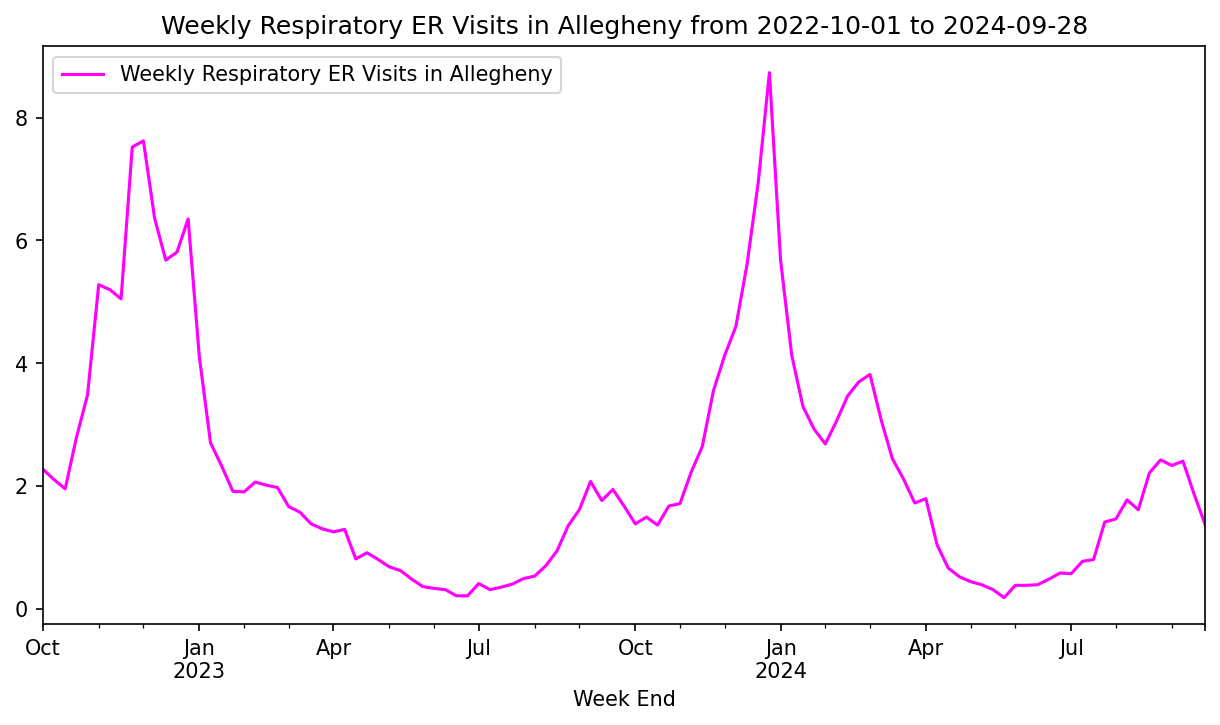

In [72]:
# Visualizing the series

# to set the plot size
plt.figure(figsize=(10, 5), dpi=150) #dpi = resolution. default 100.

# in plot method we set the label and color of the curve.
allegheny['percent_visits_combined'].plot(label='Weekly Respiratory ER Visits in Allegheny', color='magenta')

# adding title to the plot
plt.title('Weekly Respiratory ER Visits in Allegheny from {} to {}'.format('2022-10-01', '2024-09-28'))

# adding Label to the x-axis
plt.xlabel('Week End')

# adding legend to the curve
plt.legend()


We observe strong seasonality, so I doubt this series is stationary. Next step is to confirm this with the ACF plot and the ADF test

##### Step 4: Stationarizing the Data

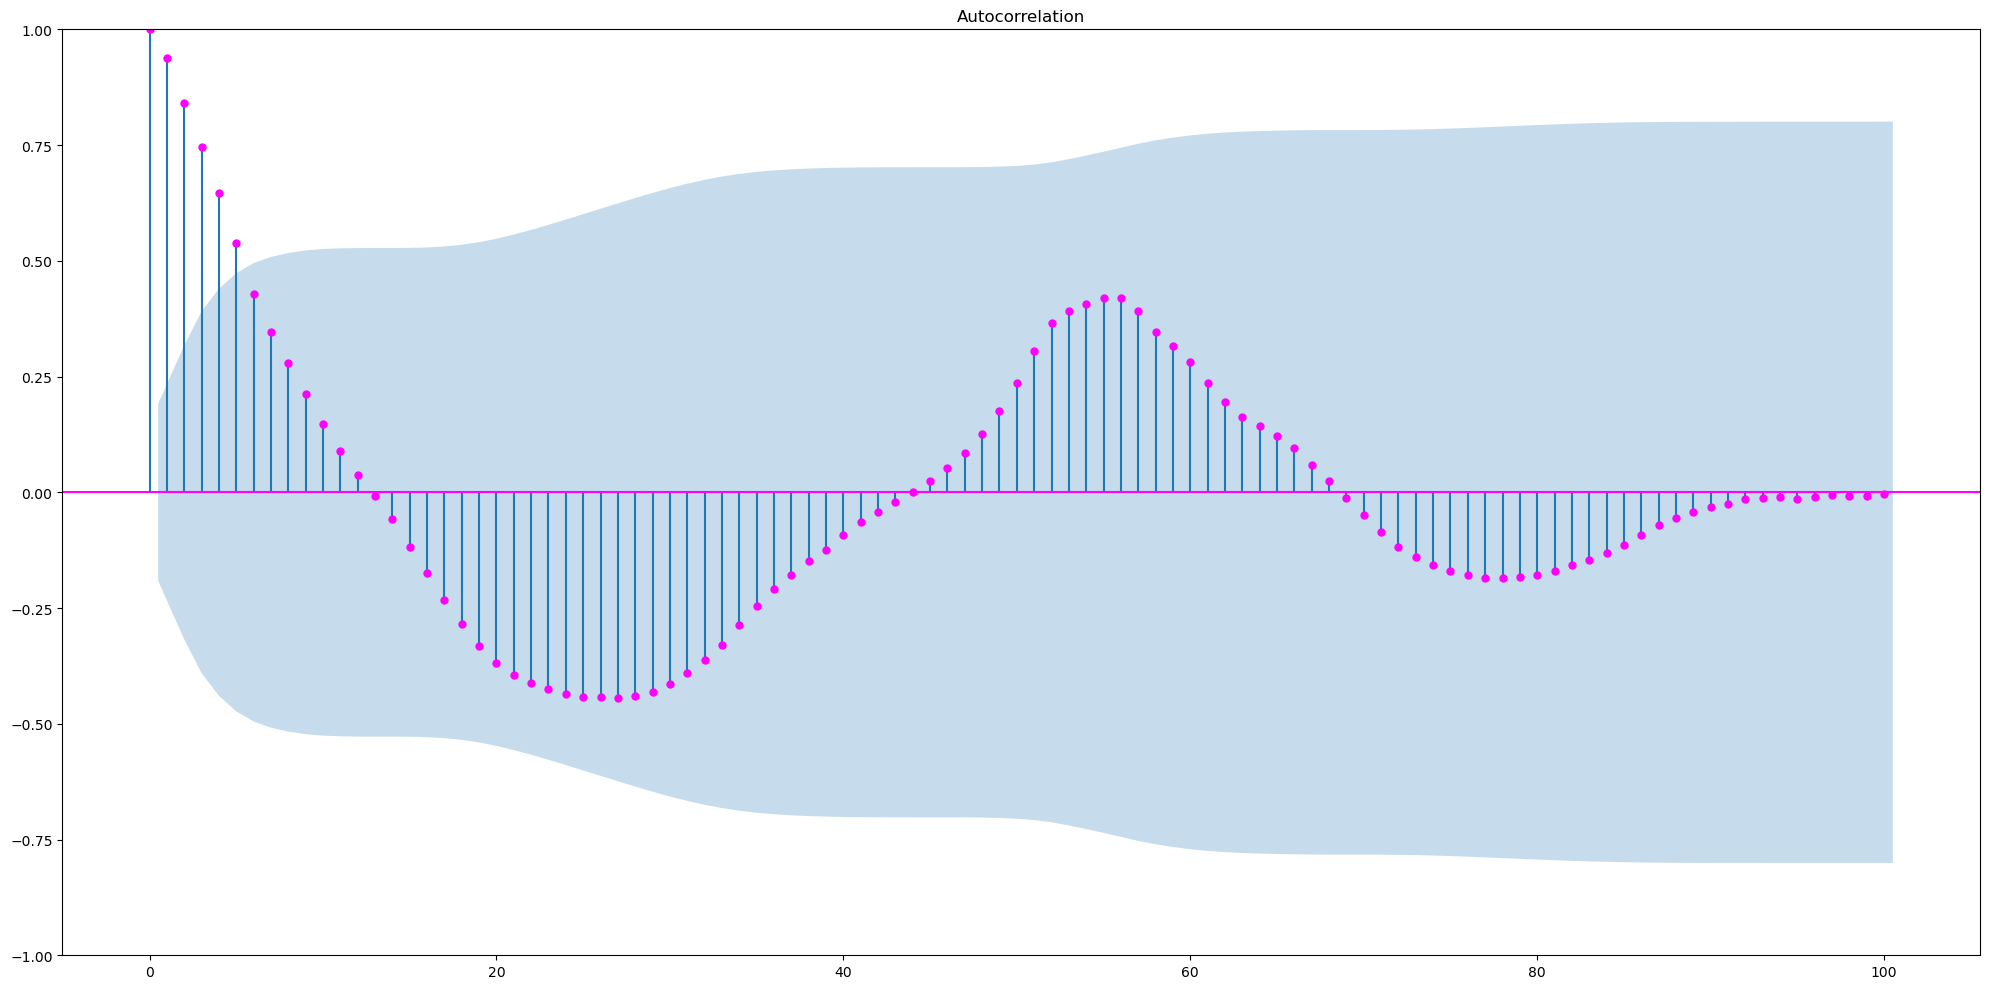

In [73]:
#check if the data is stationary

# autocorrelation plot of the dataset
fig = plot_acf(allegheny, lags=100, color="magenta")
fig.set_size_inches((20, 10))
# Tight layout to realign things
fig.tight_layout()
plt.show()

Very clear seasonality according to the ACF plot

In [74]:
X = allegheny.values

## adf test
result = adfuller(X)

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.431464
p-value: 0.133052
Critical Values:
	1%: -3.495
	5%: -2.890
	10%: -2.582


C:\Users\tanis\AppData\Local\Temp\ipykernel_20672\4166502339.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


Non-stationary data (as expected)

<Axes: xlabel='week_end'>

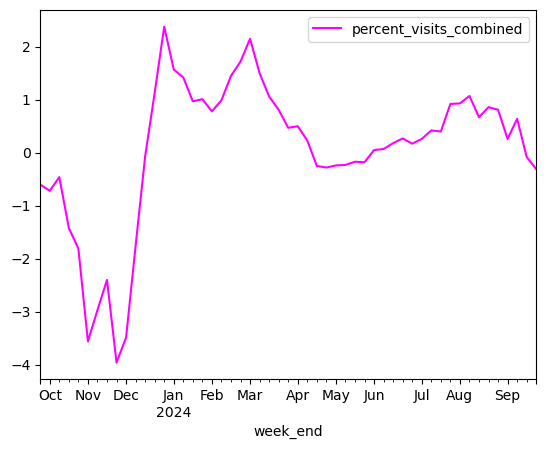

In [75]:
# since we have seasonality of every 52 weeks (yearly), we use .diff(52)
# also, after differencing, the first observation will become NA so we drop that
seasonal_diff_df = allegheny.diff(52).dropna()
seasonal_diff_df.plot(color="magenta")

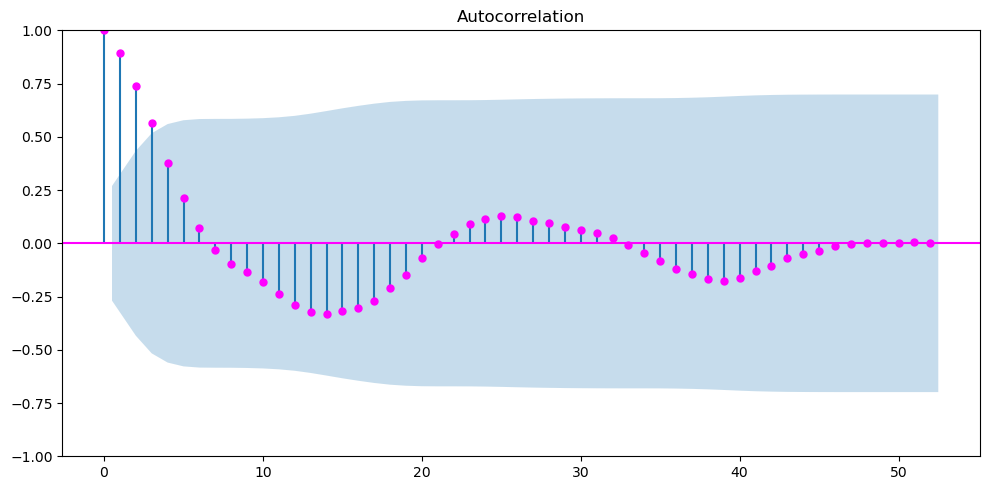

In [79]:
## Replotting the acf plot to see the result of iur deaseasonalization
# autocorrelation plot of differenced dataset
fig = plot_acf(seasonal_diff_df, lags=52, color="magenta")
fig.set_size_inches((10, 5))

# Tight layout to realign things
fig.tight_layout()
plt.show()

In [80]:
## Checking the adf test again
X = seasonal_diff_df.values

## adf test
result = adfuller(X)

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.746206
p-value: 0.003508
Critical Values:
	1%: -3.601
	5%: -2.935
	10%: -2.606


C:\Users\tanis\AppData\Local\Temp\ipykernel_20672\1238422555.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


Series has been successfully stationarized now. The stationarized ACF plot will come in handy later when we are fitting models. 

##### Step 5: Splitting Data into Train and Test Sets

In [85]:
from sklearn.model_selection import train_test_split

train_data_1, test_data_1 = train_test_split(allegheny, test_size=12, random_state=25, shuffle = False)
#shuffle = False is very important to ensure the order of the data

print(f"No. of training examples in Set 1: {train_data_1.shape[0]}")
print(f"No. of testing examples in Set 1: {test_data_1.shape[0]}")

No. of training examples in Set 1: 93
No. of testing examples in Set 1: 12


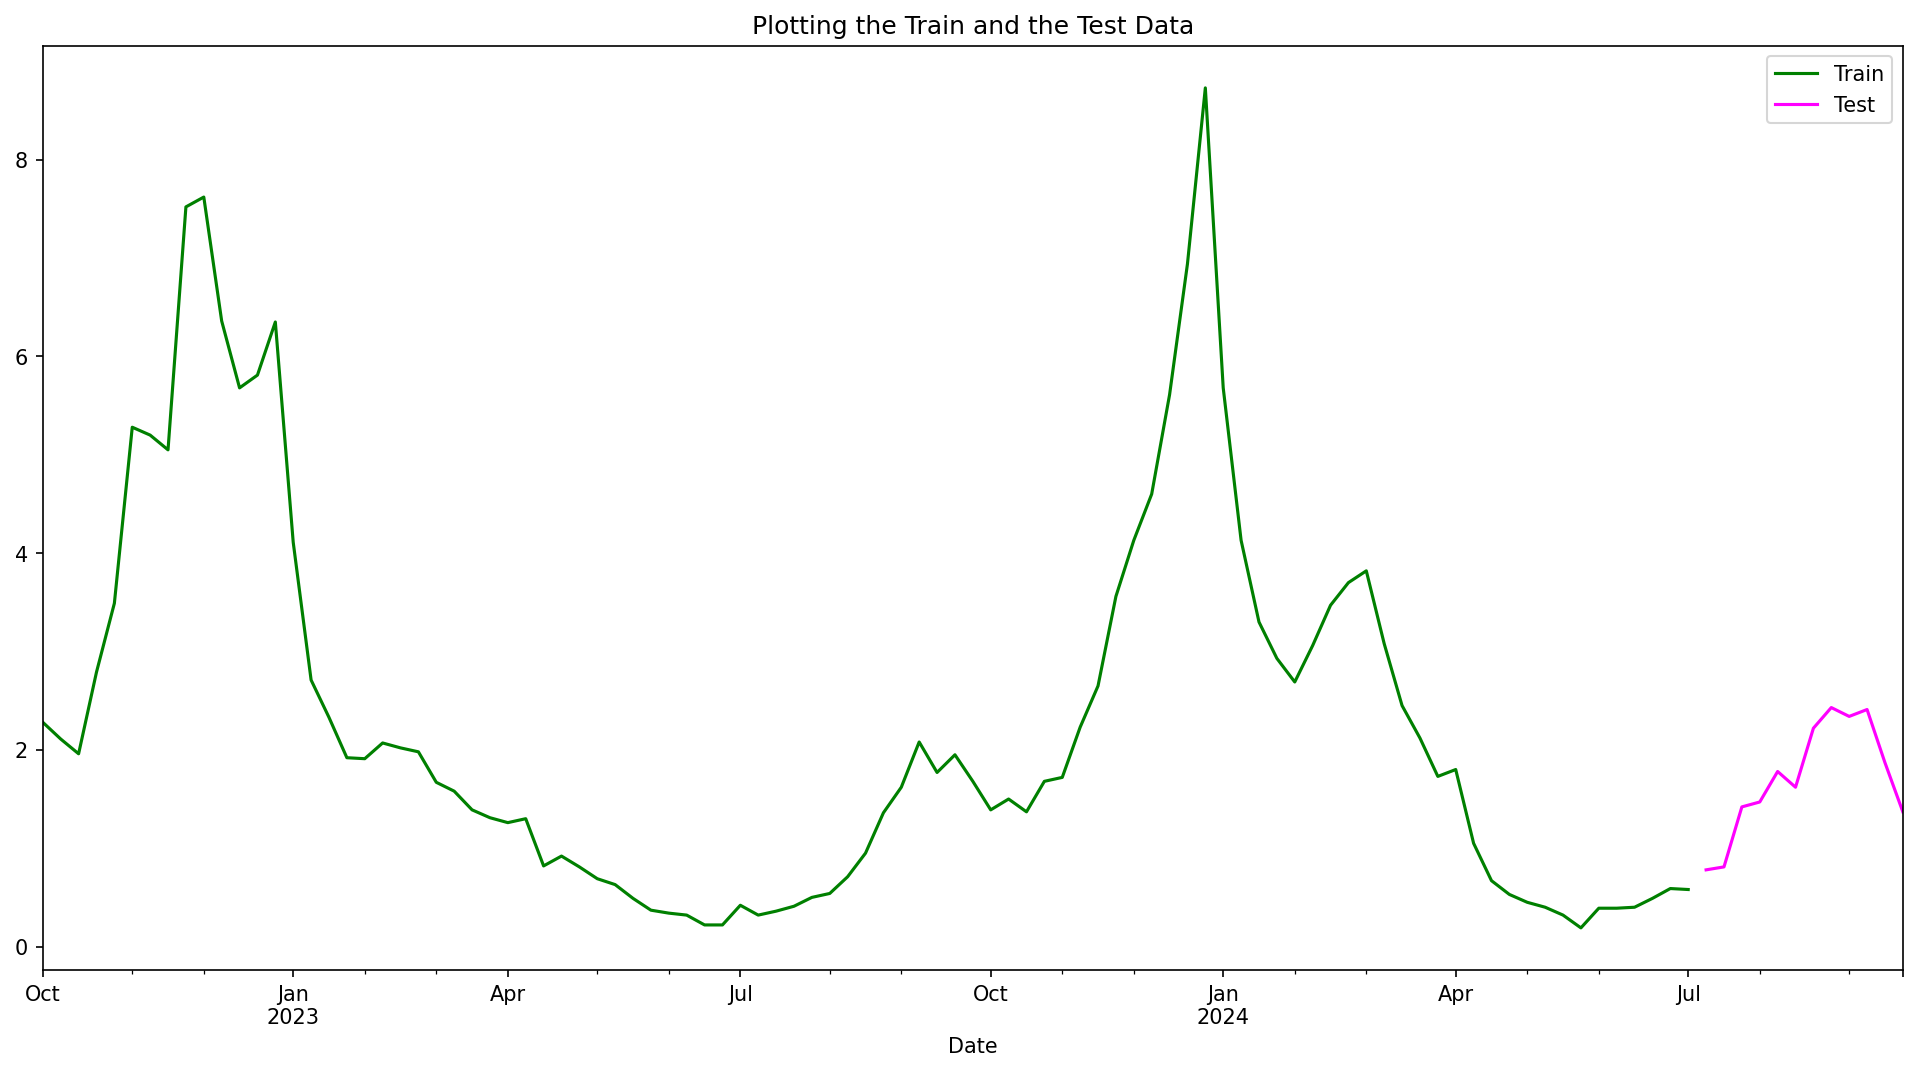

In [86]:
#Plot train and test data

# to set the plot size
plt.figure(figsize=(16, 8), dpi=150)

# using plot method to plot close prices.
# in plot method we set the label and color of the curve.
train_data_1['percent_visits_combined'].plot(label='Train', color="green")
test_data_1['percent_visits_combined'].plot(label='Test', color="magenta")

# adding Label to the x-axis
plt.xlabel('Date')
plt.title("Plotting the Train and the Test Data")
# adding legend to the curve
plt.legend()

##### Step 6: Fitting Multiple ETS and ARIMA Models

Since the ACF plot gradually tails off in a wave like pattern instead of cutting off sharply, we can choose q = 0

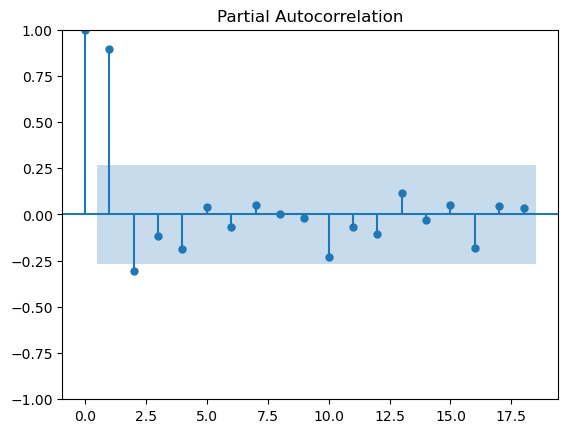

In [143]:
#plot PACF of the differenced time series.
plot_pacf(seasonal_diff_df)
plt.show()

Based on the pacf plot, p = 2

In [88]:
# Manual ARIMA
# p,d,q = 2,0,0 ARIMA Model
manual_model_1 = sm.tsa.ARIMA(train_data_1, order=(2,0,0))
manual_model_fit_1 = manual_model_1.fit()
print(manual_model_fit_1.summary())

c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


                                  SARIMAX Results                                  
Dep. Variable:     percent_visits_combined   No. Observations:                   93
Model:                      ARIMA(2, 0, 0)   Log Likelihood                 -92.377
Date:                     Sun, 27 Sep 2026   AIC                            192.754
Time:                             20:55:06   BIC                            202.884
Sample:                         10-01-2022   HQIC                           196.844
                              - 07-06-2024                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1749      1.660      1.310      0.190      -1.079       5.429
ar.L1          1.2350      0.109     11.281      0.000       1.020       1.450
ar.L2       

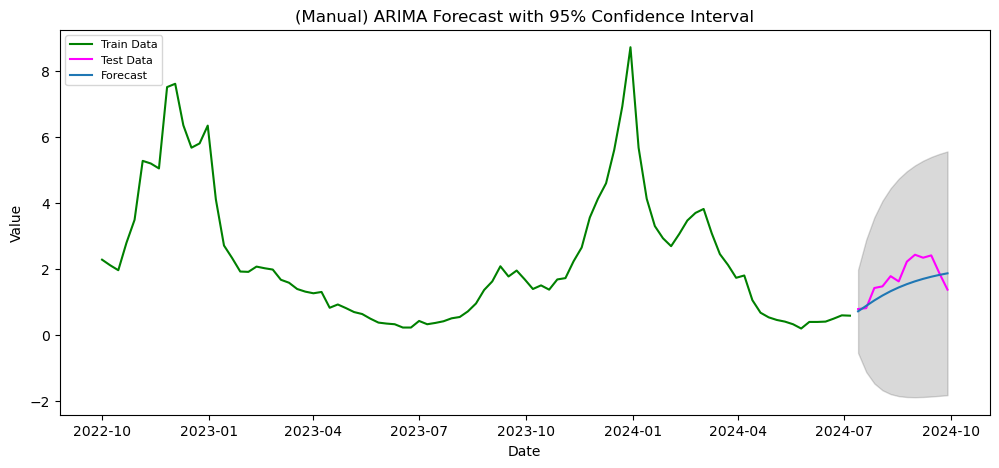

In [90]:
# Forecast
forecast_steps = 12
forecast_values = manual_model_fit_1.forecast(steps=forecast_steps)

# Calculate the standard errors of the forecasts
stderr = manual_model_fit_1.get_prediction(start=len(train_data_1), end=len(train_data_1) + forecast_steps - 1).se_mean

# Calculate lower and upper bounds for a 95% confidence interval
alpha = 0.05
z_score = 1.96  # for a 95% confidence interval
lower_bound = forecast_values - z_score * stderr
upper_bound = forecast_values + z_score * stderr

# Create pandas Series for forecasts and intervals
fc_series_set1 = pd.Series(forecast_values, index=test_data_1.index)
lower_series = pd.Series(lower_bound, index=test_data_1.index)
upper_series = pd.Series(upper_bound, index=test_data_1.index)

# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train_data_1, label='Train Data', color="green")
plt.plot(test_data_1, label='Test Data', color="magenta")
plt.plot(fc_series_set1, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.15)
plt.title('(Manual) ARIMA Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [ ]:
non_seasonal_auto_model_1 = pm.auto_arima(train_data_1, start_p=0, start_q=0,
                          test='adf',       # use adftest to find optimal 'd', like we did earlier in the notebook
                          max_p=3, max_q=3, # maximum p and q
                          m=52,              # frequency of series
                          d=None,           # let model determine 'd'
                          seasonal=False,   # No Seasonality
                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)

print(non_seasonal_auto_model_1.summary())

c:\Users\tanis\anaconda3\Lib\site-packages\pmdarima\arima\_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=198.243, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=192.552, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=191.230, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=196.308, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=193.117, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=193.136, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=194.756, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=189.272, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=191.160, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=191.179, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=190.591, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=192.798, Time=0.06 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 0.602 seconds
                               SARIMAX Results                                
Dep. Variable:       

In [92]:
# Forecast
n_periods = 12
fc_auto_nonseasonal_1, confint_1 = non_seasonal_auto_model_1.predict(n_periods=n_periods, return_conf_int=True)

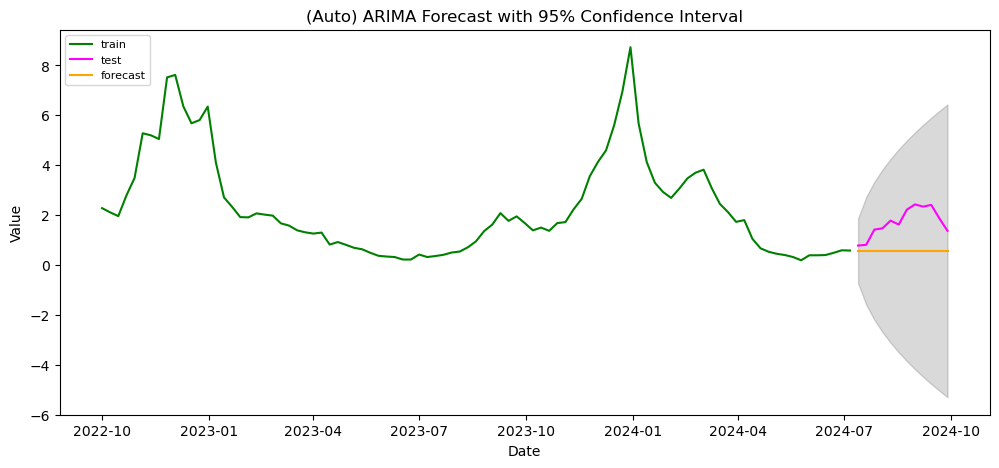

In [94]:
# make series for plotting purpose
fc_series_auto_nonseasonal_1 = pd.Series(fc_auto_nonseasonal_1, index=test_data_1.index)
lower_series = pd.Series(confint_1[:, 0], index=test_data_1.index)
upper_series = pd.Series(confint_1[:, 1], index=test_data_1.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data_1, label='train', color="green")
plt.plot(test_data_1, label='test', color="magenta")
plt.plot(fc_series_auto_nonseasonal_1, color='orange', label='forecast')
plt.title('(Auto) ARIMA Forecast with 95% Confidence Interval')
plt.fill_between(lower_series.index,
                 lower_series,
                 upper_series,
                 color='k', alpha=.15)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [96]:
# Seasonal - fit stepwise auto-ARIMA
smodel_1 = pm.auto_arima(train_data_1, start_p=1, start_q=0,
                         test='adf',
                         max_p=3, max_q=3, m=52,
                         start_P=0, seasonal=True,
                         d=None, D=1, trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

smodel_1.summary()

Performing stepwise search to minimize aic
 ARIMA(1,2,0)(0,1,1)[52]             : AIC=97.320, Time=0.53 sec
 ARIMA(0,2,0)(0,1,0)[52]             : AIC=98.475, Time=0.10 sec
 ARIMA(1,2,0)(1,1,0)[52]             : AIC=97.320, Time=0.84 sec
 ARIMA(0,2,1)(0,1,1)[52]             : AIC=92.906, Time=0.62 sec
 ARIMA(0,2,1)(0,1,0)[52]             : AIC=90.906, Time=0.13 sec
 ARIMA(0,2,1)(1,1,0)[52]             : AIC=92.906, Time=0.95 sec
 ARIMA(0,2,1)(1,1,1)[52]             : AIC=94.906, Time=1.15 sec
 ARIMA(1,2,1)(0,1,0)[52]             : AIC=inf, Time=0.76 sec
 ARIMA(0,2,2)(0,1,0)[52]             : AIC=inf, Time=0.62 sec
 ARIMA(1,2,0)(0,1,0)[52]             : AIC=95.320, Time=0.24 sec
 ARIMA(1,2,2)(0,1,0)[52]             : AIC=inf, Time=1.51 sec
 ARIMA(0,2,1)(0,1,0)[52] intercept   : AIC=92.852, Time=0.23 sec

Best model:  ARIMA(0,2,1)(0,1,0)[52]          
Total fit time: 7.699 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   93
Model:             SARIMAX(0, 2, 1)x(0, 1, [], 52)   Log Likelihood                 -43.453
Date:                             Sun, 27 Sep 2026   AIC                             90.906
Time:                                     21:12:19   BIC                             94.233
Sample:                                 10-01-2022   HQIC                            92.100
                                      - 07-06-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7581      0.082     -9.269      0.000      -0.918      -0.598
sigma2         0.5318      0.104      5.136      0.000       0.329       0.735
===================================================================================
Ljung-Box (L1) (Q):                   1.38   Jarque-Bera (JB):                 1.14
Prob(Q):                              0.24   Prob(JB):                         0.57
Heteroskedasticity (H):               0.02   Skew:                             0.10
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [97]:
# Forecast
fc_auto_seasonal_1, confint_1 = smodel_1.predict(n_periods=n_periods, return_conf_int=True)

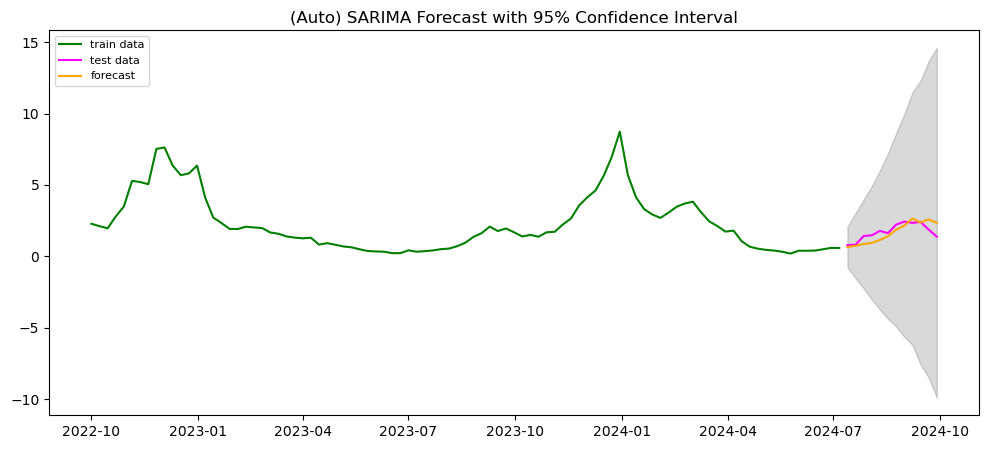

In [105]:
# make series for plotting purpose
fc_series_auto_seasonal_1 = pd.Series(fc_auto_seasonal_1, index=test_data_1.index)
lower_series = pd.Series(confint_1[:, 0], index=test_data_1.index)
upper_series = pd.Series(confint_1[:, 1], index=test_data_1.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data_1, label='train data', color="green")
plt.plot(test_data_1, label='test data', color="magenta")
plt.plot(fc_series_auto_seasonal_1, label='forecast', color="orange")
plt.fill_between(lower_series.index, lower_series, upper_series,
                 color='k', alpha=.15)
plt.title('(Auto) SARIMA Forecast with 95% Confidence Interval')
plt.legend(loc='upper left', fontsize=8)
plt.show()

c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:            percent_visits_combined   No. Observations:                   93
Model:             SARIMAX(2, 0, 0)x(0, 1, 0, 52)   Log Likelihood                 -39.574
Date:                            Sun, 27 Sep 2026   AIC                             85.147
Time:                                    21:23:49   BIC                             90.288
Sample:                                10-01-2022   HQIC                            87.019
                                     - 07-06-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1937      0.130      9.197      0.000       0.939       1.448
ar.L2         -0.3415      0.121   

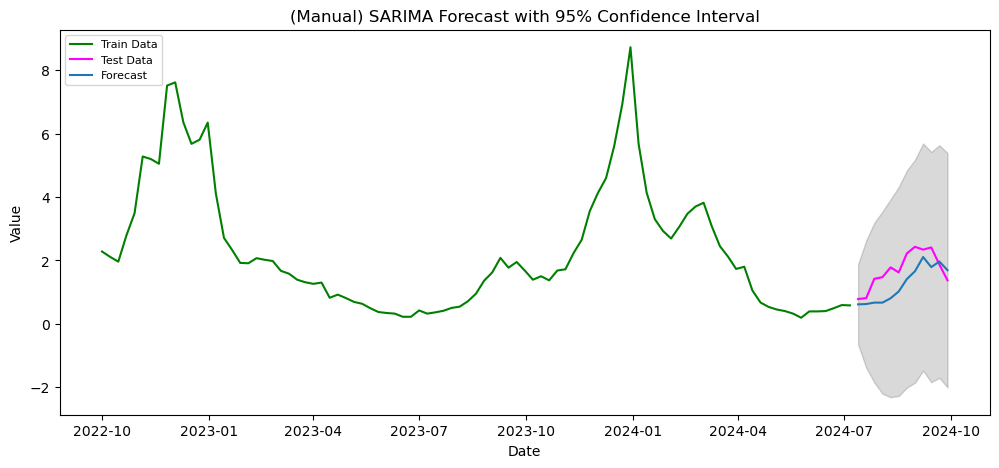

In [107]:
# p,d,q = 2,0,0; P,D,Q, s = 0,1,0, 52 
#STARTING WITH P and Q equals to 0 because the dataset is small and cannot 
# inspect lag 52 after differencing (throwing error)

# Why do we look at P and Q of SARIMAX after seasonally-differencing?? It is because
# SARIMAX is looking at if there is any seasonal relation still left after the 
# seasonal differencing has been done.

manual_sarima_1 = sm.tsa.SARIMAX(train_data_1, order=(2,0,0), 
seasonal_order=(0,1,0,52)) 
manual_sarima_fit_1 = manual_sarima_1.fit()
print(manual_sarima_fit_1.summary())

forecast_steps = 12
forecast_values = manual_sarima_fit_1.forecast(steps=forecast_steps)
srderr = manual_sarima_fit_1.get_prediction(start=len(train_data_1), end=len(train_data_1))

alpha = 0.05
z_score = 1.96  # for a 95% confidence interval
lower_bound = forecast_values - z_score * stderr
upper_bound = forecast_values + z_score * stderr

# Create pandas Series for forecasts and intervals
fc_series_manualSARIMA_1 = pd.Series(forecast_values, index=test_data_1.index)
lower_series = pd.Series(lower_bound, index=test_data_1.index)
upper_series = pd.Series(upper_bound, index=test_data_1.index)


# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train_data_1, label='Train Data', color="green")
plt.plot(test_data_1, label='Test Data', color="magenta")
plt.plot(fc_series_manualSARIMA_1, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.15)
plt.title('(Manual) SARIMA Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [108]:
from statsmodels.tsa.api import SimpleExpSmoothing
# Simple Exponential Smoothing Model
## added the initialization_method="estimated" because kept getting an error about it otherwise.
#First Instance
ins1_set1 = SimpleExpSmoothing(train_data_1, initialization_method="estimated").fit(smoothing_level=0.2, optimized=False)
ins_cast1_set1 = ins1_set1.forecast(12).rename('alpha=0.2')

#Second Instance
ins2_set1 = SimpleExpSmoothing(train_data_1, initialization_method="estimated").fit(smoothing_level=0.5, optimized=False)
ins_cast2_set1 = ins2_set1.forecast(12).rename('alpha=0.5')

#Third Instance
ins3_set1 = SimpleExpSmoothing(train_data_1, initialization_method="estimated").fit()
ins_cast3_set1 = ins3_set1.forecast(12).rename('alpha=%s'%ins3_set1.model.params['smoothing_level'])


c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


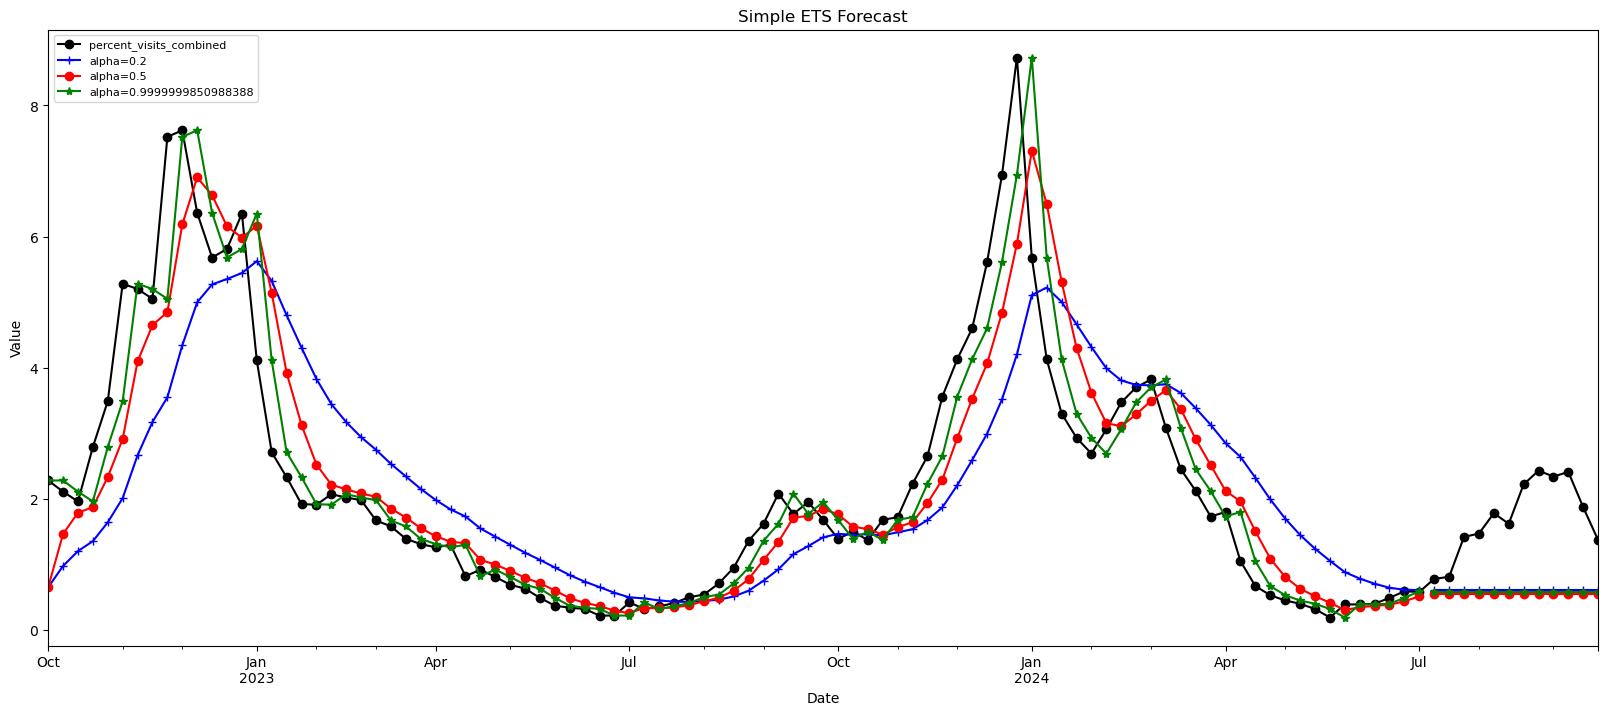

In [116]:
#After creating model we will visualize the plot
ax = allegheny.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for alpha =0.2
ins_cast1_set1.plot(marker='+', ax=ax, color='blue', legend=True)
ins1_set1.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for alpha = 0.5
ins_cast2_set1.plot(marker='o', ax=ax, color='red', legend=True)
ins2_set1.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for alpha=Optimized by statsmodel
ins_cast3_set1.plot(marker='*', ax=ax, color='green', legend=True)
ins3_set1.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('Simple ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)

plt.show()

In [112]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
## double ETS
double_ets_add_set1 = ExponentialSmoothing(train_data_1, trend = 'add').fit()
double_ets_mul_set1 = ExponentialSmoothing(train_data_1, trend = 'mul').fit()

double_ets_add_pred_set1 = double_ets_add_set1.forecast(12)
double_ets_mul_pred_set1 = double_ets_mul_set1.forecast(12)

c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


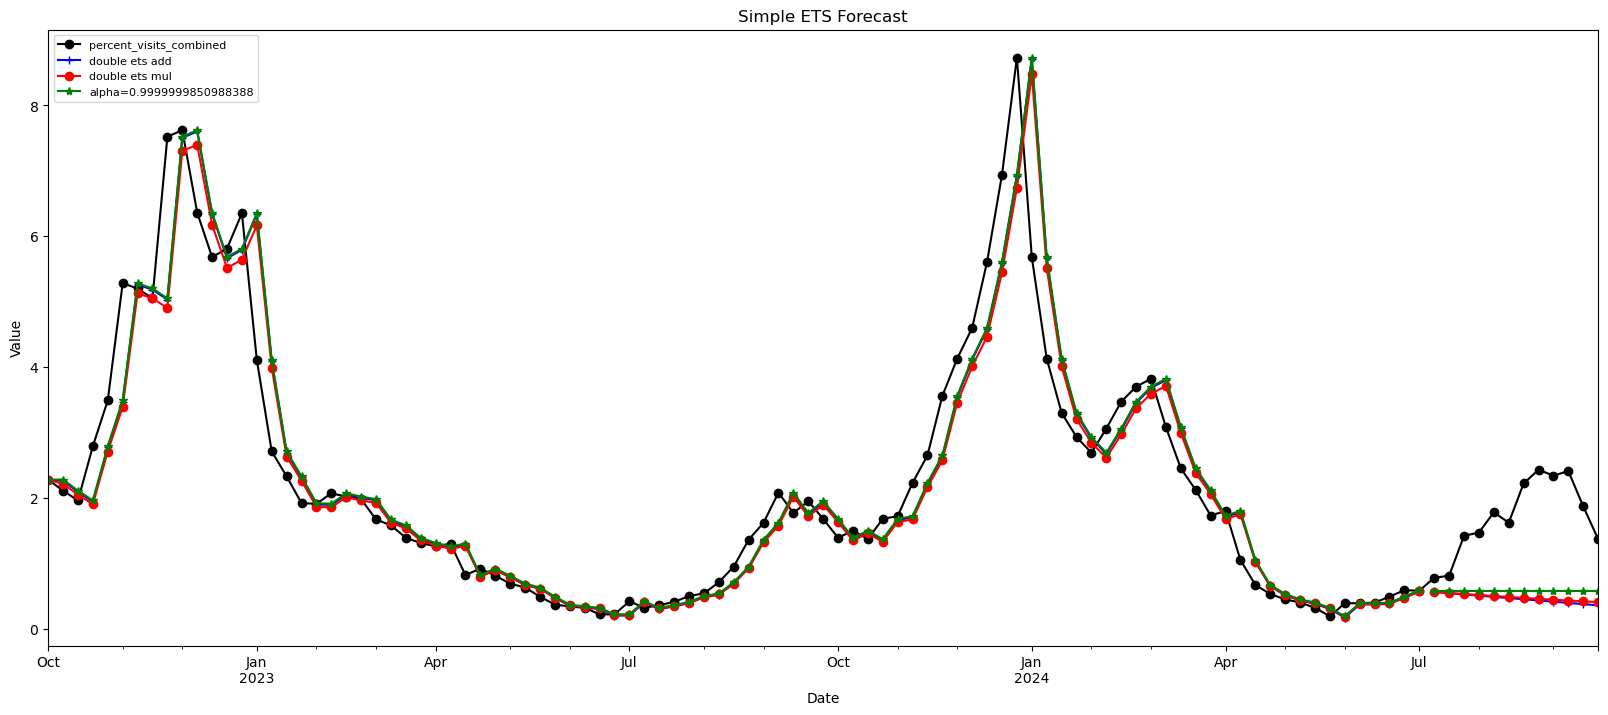

In [ ]:
#plot the train, test, and predictions

#After creating model we will visualize the plot
ax = allegheny.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for double ETS additive
double_ets_add_pred_set1.plot(marker='+', ax=ax, color='blue', legend=True, label = 'double ets add')
double_ets_add_set1.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for double ETS multiplicative
double_ets_mul_pred_set1.plot(marker='o', ax=ax, color='red', legend=True, label = 'double ets mul')
double_ets_mul_set1.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for simple exponential smooting alpha=Optimized by statsmodel
ins_cast3_set1.plot(marker='*', ax=ax, color='green', legend=True)
ins3_set1.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('Double ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()



In [117]:
### triple ETS
# triple ETS - Holt Winter's Seasonal Method
triple_ets_add_set1 = ExponentialSmoothing(train_data_1, trend = 'add', seasonal = 'add', seasonal_periods=12).fit()
triple_ets_mul_set1 = ExponentialSmoothing(train_data_1, trend = 'mul', seasonal = 'mul', seasonal_periods=12).fit()

triple_ets_add_pred_set1 = triple_ets_add_set1.forecast(12)
triple_ets_mul_pred_set1 = triple_ets_mul_set1.forecast(12)

c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


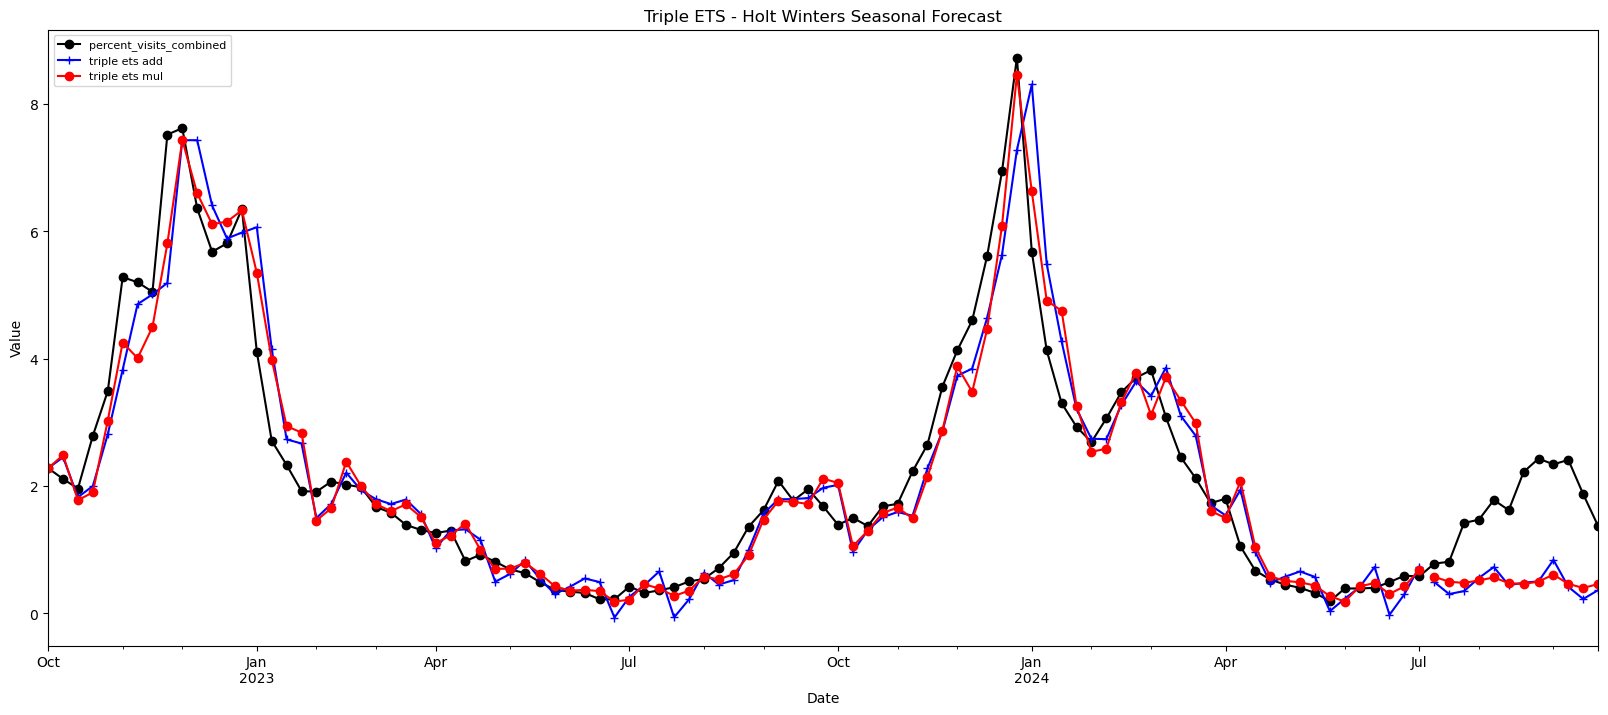

In [118]:
#plot the train, test, and predictions

#After creating model we will visualize the plot
ax = allegheny.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for double ETS additive
triple_ets_add_pred_set1.plot(marker='+', ax=ax, color='blue', legend=True, label = 'triple ets add')
triple_ets_add_set1.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for double ETS multiplicative
triple_ets_mul_pred_set1.plot(marker='o', ax=ax, color='red', legend=True, label = 'triple ets mul')
triple_ets_mul_set1.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for simple exponential smooting alpha=Optimized by statsmodel
#ins_cast3.plot(marker='*', ax=ax, color='green', legend=True)
#ins3.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('Triple ETS - Holt Winters Seasonal Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

##### Step 7: Evaluating Models

In [135]:
#define metrics dataframe which will be used below for storing results
metrics_dataframe = pd.DataFrame(columns=['Model', 'RMSE', 'MAE', 'MAPE',
                                          "MASE", "WAPE"])
def metrics_cal(actuals, predictions, model, data):
    mse = mean_squared_error(actuals, predictions)
    rmse = sqrt(mse)
    mae = mean_absolute_error(actuals, predictions)
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

    # additional evaluation metrics
    mase = mae / np.mean(np.abs(np.diff(data.values.flatten())))
    wape = np.sum(np.abs(actuals - predictions)) / np.sum(np.abs(actuals)) * 100

    df = pd.DataFrame({'Model': [model],
                       'RMSE': [rmse],
                       'MAE': [mae],
                       'MAPE': [mape],
                       'MASE': [mase],
                       'WAPE': [wape]})

    global metrics_dataframe
    metrics_dataframe = pd.concat([metrics_dataframe, df], ignore_index=True)
    return metrics_dataframe

In [141]:
test_pred_df = test_data_1.copy()

test_pred_df = test_pred_df.assign(
    Simple_02=ins_cast1_set1.values.flatten(),
    Simple_05=ins_cast2_set1.values.flatten(),
    Simple_1=ins_cast3_set1.values.flatten(),
    Double_Add=double_ets_add_pred_set1.values.flatten(),
    Double_Mul=double_ets_mul_pred_set1.values.flatten(),
    Triple_Add=triple_ets_add_pred_set1.values.flatten(),
    Triple_Mul=triple_ets_mul_pred_set1.values.flatten(),
    Manual_ARIMA=fc_series_set1.values.flatten(),
    Manual_SARIMA=fc_series_manualSARIMA_1.values.flatten(),
    Auto_ARIMA=fc_series_auto_nonseasonal_1.values.flatten(),
    Auto_SARIMA=fc_series_auto_seasonal_1.values.flatten()
)

prediction_columns = [
    "Simple_02",
    "Simple_05",
    "Simple_1",
    "Double_Add",
    "Double_Mul",
    "Triple_Add",
    "Triple_Mul",
    "Manual_ARIMA",
    "Manual_SARIMA",
    "Auto_ARIMA",
    "Auto_SARIMA"
]

test_pred_df["Average_Prediction"] = (
    test_pred_df[prediction_columns].mean(axis=1)
)

test_pred_df

,percent_visits_combined,Simple_02,Simple_05,Simple_1,Double_Add,Double_Mul,Triple_Add,Triple_Mul,Manual_ARIMA,Manual_SARIMA,Auto_ARIMA,Auto_SARIMA,Average_Prediction
week_end,,,,,,,,,,,,,
2024-07-13,0.78,0.602908,0.546776,0.58,0.561522,0.563102,0.491443,0.573310,0.712550,0.612307,0.568619,0.653982,0.587865
2024-07-20,0.81,0.602908,0.546776,0.58,0.543044,0.546696,0.302878,0.496404,0.879445,0.622389,0.568619,0.737963,0.584284
2024-07-27,1.42,0.602908,0.546776,0.58,0.524565,0.530769,0.348624,0.477099,1.043127,0.667366,0.568619,0.861945,0.613800
2024-08-03,1.47,0.602908,0.546776,0.58,0.506087,0.515305,0.555823,0.516731,1.191849,0.667254,0.568619,0.935926,0.653389
2024-08-10,1.78,0.602908,0.546776,0.58,0.487609,0.500292,0.727067,0.563107,1.323124,0.804747,0.568619,1.139908,0.713105
2024-08-17,1.62,0.602908,0.546776,0.58,0.469131,0.485716,0.440810,0.474159,1.437641,1.019642,0.568619,1.413889,0.730845
2024-08-24,2.22,0.602908,0.546776,0.58,0.450652,0.471565,0.480788,0.459794,1.537047,1.410776,0.568619,1.857871,0.815163
2024-08-31,2.43,0.602908,0.546776,0.58,0.432174,0.457826,0.502018,0.498799,1.623156,1.656828,0.568619,2.151852,0.874632
2024-09-07,2.34,0.602908,0.546776,0.58,0.413696,0.444488,0.839500,0.607890,1.697678,2.106622,0.568619,2.645834,1.004910


In [142]:
# calculate metrics for each model

metrics_cal(
    test_data_1.values.flatten(),
    ins_cast1_set1.values.flatten(),
    "Simple 0.2",
    train_data_1
)

metrics_cal(
    test_data_1.values.flatten(),
    ins_cast2_set1.values.flatten(),
    "Simple 0.5",
    train_data_1
)

metrics_cal(
    test_data_1.values.flatten(),
    ins_cast3_set1.values.flatten(),
    "Simple 1",
    train_data_1
)

metrics_cal(
    test_data_1.values.flatten(),
    double_ets_add_pred_set1.values.flatten(),
    "Double Add",
    train_data_1
)

metrics_cal(
    test_data_1.values.flatten(),
    double_ets_mul_pred_set1.values.flatten(),
    "Double Mul",
    train_data_1
)

metrics_cal(
    test_data_1.values.flatten(),
    triple_ets_add_pred_set1.values.flatten(),
    "Triple Add",
    train_data_1
)

metrics_cal(
    test_data_1.values.flatten(),
    triple_ets_mul_pred_set1.values.flatten(),
    "Triple Mul",
    train_data_1
)

metrics_cal(
    test_data_1.values.flatten(),
    fc_series_set1.values.flatten(),
    "Manual ARIMA",
    train_data_1
)

metrics_cal(
    test_data_1.values.flatten(),
    fc_series_manualSARIMA_1.values.flatten(),
    "Manual SARIMA",
    train_data_1
)

metrics_cal(
    test_data_1.values.flatten(),
    fc_series_auto_nonseasonal_1.values.flatten(),
    "Auto ARIMA",
    train_data_1
)

metrics_cal(
    test_data_1.values.flatten(),
    fc_series_auto_seasonal_1.values.flatten(),
    "Auto SARIMA",
    train_data_1
)


allegheny_combined = metrics_dataframe.copy()

allegheny_combined

,Model,RMSE,MAE,MAPE,MASE,WAPE
0,Simple 0.2,1.236394,1.107092,59.559243,2.691662,64.742249
1,Simple 0.5,1.286898,1.163224,63.324317,2.828134,68.024780
2,Simple 1,1.256947,1.130000,61.095794,2.747357,66.081871
3,Double Add,1.384138,1.250109,67.898864,3.039376,73.105763
4,Double Mul,1.361063,1.228915,66.726156,2.987848,71.866369
5,Triple Add,1.338910,1.235519,69.593700,3.003905,72.252577
6,Triple Mul,1.333884,1.211089,66.195170,2.944508,70.823923
7,Manual ARIMA,0.471642,0.396613,21.408832,0.964281,23.193740
8,Manual SARIMA,0.604800,0.528054,31.374521,1.283852,30.880350
9,Auto ARIMA,1.267189,1.141381,61.859172,2.775027,66.747413


In [138]:
metrics = ["RMSE", "MAE", "MAPE", "MASE", "WAPE"]
model_dict = {}
for metric in metrics:
    sorted_models = allegheny_combined.sort_values(by=metric)["Model"]
    score = 0
    for model in sorted_models:
        if model in model_dict.keys(): 
            model_dict[model] += score
        else:
            model_dict[model] = score
        score += 1
model_dict

{'Manual ARIMA': 0,
 'Auto SARIMA': 5,
 'Manual SARIMA': 10,
 'Simple 0.2': 15,
 'Simple 1': 20,
 'Auto ARIMA': 25,
 'Simple 0.5': 30,
 'Triple Mul': 35,
 'Triple Add': 45,
 'Double Mul': 41,
 'Double Add': 49}

### Approach 2: Individual Diseases (RSV, Covid, Influenza) but at PA Level

In [144]:
# ============================================================
# CONFIGURATION
# ============================================================

TARGETS = [
    "percent_visits_covid",
    "percent_visits_influenza",
    "percent_visits_rsv"
]

COMBINED_TARGET = "percent_visits_combined"

TEST_SIZE = 12

# Weekly data with yearly seasonality
SEASONAL_PERIOD = 52


# Your original manual model used p=2, q=0.
# We keep those values but determine d using TRAINING DATA ONLY.
MANUAL_P = 2
MANUAL_Q = 0

# Your original manual SARIMA used P=0, D=1, Q=0, s=52.
MANUAL_P_SEASONAL = 0
MANUAL_D_SEASONAL = 1
MANUAL_Q_SEASONAL = 0


MODEL_NAMES = [
    "Manual ARIMA",
    "Auto ARIMA",
    "Manual SARIMA",
    "Auto SARIMA",
    "Single ETS",
    "Double ETS",
    "Triple ETS"
]